In [1]:
# Inputs: fill these paths and numeric values before running the analysis.
# Keep everything in a projected CRS with meter units (for distance and area).

INPUTS = {
    "galapagos_boundary": "C:/Galapagos_IERSE/01_Organizacion_Territorial/Parroquias_Galapagos_CONALI_2018.shp",      # Polygon boundary (shp/gpkg/geojson)
    "wind_speed_raster": "C:/HyGalapagos/inputs/wind-speed_100m_galapagos_clipped.tif",  # Wind speed raster
    "dem": "C:/Galapagos_IERSE/dem_30m.tif",       # DEM raster used to derive terrain suitability
    "roads": "C:/Galapagos_IERSE/01_Vialidad/Red_vial_Galapagos_OSM_2023.shp",                   # Roads vector
    "substations": "C:/Galapagos_IERSE/subestaciones.shp",             # Substations vector
    "poblados": "C:/Galapagos_IERSE/poblados/poblado_68a9d757b1b9ed0b86e3d58153578f13.shp",  # Population centers / settlements
    "land_cover": "C:/Galapagos_IERSE/cobertura/A_ECOSISTEMAS_NATIVOS_2016.shp",
    "land_cover_remap": "C:/HyGalapagos/inputs/remap_eolico_fuzzy.csv",
}

PARAMS = {
    "threshold": 0.7,                    # Fuzzy suitability threshold in [0, 1]
    "land_cover_field": "FROM",         # Field in land-cover layer containing classes used in remap_eolico_fuzzy.csv
    "analysis_crs": "EPSG:32715",       # Projected CRS in meters for distance and slope analysis
    # Each sigmoid control pair maps approximately from 0.05 to 0.95 membership.
    "wind": {
        "function": "sigmoidal",
        "direction": "increasing",
        "control_points": {
            "a": 5.0,                    # Very low suitability begins
            "b": 6.5,                    # Very high suitability
        },
    },
    "slope": {
        "function": "sigmoidal",
        "direction": "decreasing",
        "control_points": {
            "c": 3.0,                    # Very high suitability below this
            "d": 30.0,                   # Very low suitability above this
        },
    },
    "roads": {
        "function": "sigmoidal",
        "direction": "decreasing",
        "control_points": {
            "c": 3000.0,                 # m
            "d": 30000.0,                # m
        },
    },
    "substations": {
        "function": "sigmoidal",
        "direction": "decreasing",
        "control_points": {
            "c": 1000.0,                 # m
            "d": 15000.0,                # m
        },
    },
    "urban": {
        "function": "sigmoidal",
        "direction": "increasing",
        "control_points": {
            "a": 1000.0,                 # m
            "b": 10000.0,                # m
        },
    },
}

# Change this value to switch between scenario_1 and scenario_2.
ACTIVE_WEIGHT_SCENARIO = "scenario_1"

WEIGHT_SCENARIOS = {
    "scenario_1": {
        "wind": 0.45,
        "terrain": 0.20,
        "roads": 0.10,
        "substations": 0.05,
        "landuse": 0.15,
        "poblados": 0.05,
    },
    "scenario_2": {
        "wind": 0.25,
        "terrain": 0.15,
        "roads": 0.30,
        "substations": 0.15,
        "landuse": 0.10,
        "poblados": 0.05,
    },
}

if ACTIVE_WEIGHT_SCENARIO not in WEIGHT_SCENARIOS:
    raise ValueError(
        f"Unknown scenario {ACTIVE_WEIGHT_SCENARIO!r}. "
        f"Choose one of: {list(WEIGHT_SCENARIOS)}"
    )

WEIGHTS = WEIGHT_SCENARIOS[ACTIVE_WEIGHT_SCENARIO].copy()
PARAMS["weight_scenario"] = ACTIVE_WEIGHT_SCENARIO

SCENARIO_OUTPUT_DIRS = {
    "scenario_1": "C:/HyGalapagos/outputs_eolico/scenario_1",
    "scenario_2": "C:/HyGalapagos/outputs_eolico/scenario_2",
}

SAVE_INTERMEDIATE_RESULTS = False
OUTPUT_DIR = SCENARIO_OUTPUT_DIRS[ACTIVE_WEIGHT_SCENARIO]

# Default behavior: only keep the minimum results needed for downstream use.
# Set SAVE_INTERMEDIATE_RESULTS = True to retain the full intermediate raster stack too.
PARAMS["save_intermediate_results"] = SAVE_INTERMEDIATE_RESULTS

ALL_OUTPUTS = {
    "dem_clipped": f"{OUTPUT_DIR}/dem_clipped.tif",
    "slope_degrees": f"{OUTPUT_DIR}/slope_degrees.tif",
    "terrain_reclass": f"{OUTPUT_DIR}/terrain_reclass.tif",
    "wind_reclass": f"{OUTPUT_DIR}/wind_reclass.tif",
    "roads_distance": f"{OUTPUT_DIR}/roads_distance.tif",
    "roads_reclass": f"{OUTPUT_DIR}/roads_reclass.tif",
    "substations_distance": f"{OUTPUT_DIR}/substations_distance.tif",
    "substations_reclass": f"{OUTPUT_DIR}/substations_reclass.tif",
    "poblados_distance": f"{OUTPUT_DIR}/poblados_distance.tif",
    "poblados_reclass": f"{OUTPUT_DIR}/poblados_reclass.tif",
    "land_cover_reclass": f"{OUTPUT_DIR}/land_cover_reclass.tif",
    "weighted_suitability": f"{OUTPUT_DIR}/weighted_suitability.tif",
    "candidate_raster": f"{OUTPUT_DIR}/candidate_raster.tif",
    "candidate_polygons": f"{OUTPUT_DIR}/candidate_polygons.gpkg",
}

MINIMUM_OUTPUTS = {
    "weighted_suitability": ALL_OUTPUTS["weighted_suitability"],
    "candidate_raster": ALL_OUTPUTS["candidate_raster"],
    "candidate_polygons": ALL_OUTPUTS["candidate_polygons"],
}

OUTPUTS = MINIMUM_OUTPUTS if not SAVE_INTERMEDIATE_RESULTS else ALL_OUTPUTS

In [22]:
import csv
import re
import numpy as np
import geopandas as gpd
import rasterio
from rasterio.enums import Resampling
from rasterio.features import rasterize, shapes
from rasterio.warp import calculate_default_transform, reproject
from rasterio.features import geometry_mask
from scipy.ndimage import distance_transform_edt, find_objects, label
from pathlib import Path
from datetime import datetime


In [23]:
def _require_non_empty(mapping, mapping_name):
    missing = [key for key, value in mapping.items() if value in (None, "")]
    if missing:
        raise ValueError(f"Missing values in {mapping_name}: {missing}")


def _validate_weights(weights):
    for key, value in weights.items():
        if value is None:
            raise ValueError(f"Weight '{key}' is empty.")
    total = float(sum(weights.values()))
    if not np.isclose(total, 1.0, atol=1e-6):
        raise ValueError(f"Weights must sum to 1.0. Current sum: {total}")


def _project_raster_profile(src_path, dst_crs):
    with rasterio.open(src_path) as src:
        transform, width, height = calculate_default_transform(
            src.crs,
            dst_crs,
            src.width,
            src.height,
            *src.bounds,
        )
        profile = src.profile.copy()
        profile.update(
            crs=dst_crs,
            transform=transform,
            width=width,
            height=height,
            nodata=src.nodata if src.nodata is not None else -9999.0,
        )
    return profile


def _reproject_to_template(src_path, template_profile, resampling=Resampling.bilinear):
    destination = np.full(
        (template_profile["height"], template_profile["width"]),
        np.nan,
        dtype="float32",
    )
    with rasterio.open(src_path) as src:
        reproject(
            source=rasterio.band(src, 1),
            destination=destination,
            src_transform=src.transform,
            src_crs=src.crs,
            dst_transform=template_profile["transform"],
            dst_crs=template_profile["crs"],
            src_nodata=src.nodata,
            dst_nodata=np.nan,
            resampling=resampling,
        )
    return destination


def _clip_array_to_boundary(array, transform, boundary_gdf):
    boundary_mask = geometry_mask(
        geometries=boundary_gdf.geometry,
        out_shape=array.shape,
        transform=transform,
        invert=True,
    )
    return np.where(boundary_mask, array, np.nan)


def _rasterize_features(features_gdf, out_shape, transform):
    if features_gdf.empty:
        raise ValueError("Input feature layer is empty.")
    geometries = [
        (geometry, 1)
        for geometry in features_gdf.geometry
        if geometry is not None and not geometry.is_empty
    ]
    if not geometries:
        raise ValueError("Input feature layer contains no valid geometries.")
    return rasterize(
        geometries,
        out_shape=out_shape,
        transform=transform,
        fill=0,
        dtype="uint8",
    )


def _distance_within_boundary_components(feature_raster, boundary_mask, transform):
    pixel_size_y = abs(transform.e)
    pixel_size_x = abs(transform.a)
    feature_mask = feature_raster == 1
    component_labels, _ = label(boundary_mask.astype("uint8"))
    component_slices = find_objects(component_labels)
    output = np.full(feature_raster.shape, np.nan, dtype="float32")

    for component_id, component_slice in enumerate(component_slices, start=1):
        if component_slice is None:
            continue
        component = component_labels[component_slice] == component_id
        component_features = feature_mask[component_slice] & component
        if not np.any(component_features):
            continue
        local_distance = distance_transform_edt(
            ~component_features,
            sampling=(pixel_size_y, pixel_size_x),
        ).astype("float32")
        output_view = output[component_slice]
        output_view[component] = local_distance[component]
        output[component_slice] = output_view

    return output


def _slope_from_dem(dem, transform):
    pixel_size_y = abs(transform.e)
    pixel_size_x = abs(transform.a)
    dem_filled = np.where(np.isfinite(dem), dem, np.nan)
    dz_dy, dz_dx = np.gradient(dem_filled, pixel_size_y, pixel_size_x)
    slope_radians = np.arctan(np.sqrt(dz_dx ** 2 + dz_dy ** 2))
    slope_degrees = np.degrees(slope_radians).astype("float32")
    slope_degrees[~np.isfinite(dem)] = np.nan
    return slope_degrees


def _load_land_cover_remap(remap_path):
    remap = {}
    with open(remap_path, "r", encoding="utf-8-sig", newline="") as remap_file:
        reader = csv.DictReader(remap_file)
        required_columns = {"FROM", "OUT"}
        if not required_columns.issubset(set(reader.fieldnames or [])):
            raise ValueError("Land-cover remap file must include columns: FROM, OUT")
        for row in reader:
            key = str(row["FROM"]).strip()
            if key:
                remap[key] = float(np.clip(float(row["OUT"]), 0.0, 1.0))
    if not remap:
        raise ValueError("Land-cover remap table is empty.")
    return remap


def _detect_land_cover_field(land_cover_gdf, remap_dict, preferred_field=None):
    if preferred_field and preferred_field in land_cover_gdf.columns:
        return preferred_field
    class_columns = [
        column
        for column in land_cover_gdf.columns
        if land_cover_gdf[column].dtype == "object"
    ]
    if not class_columns:
        raise ValueError("No text columns found in land-cover layer.")
    remap_keys = set(remap_dict)
    matches_by_column = {
        column: len(
            set(land_cover_gdf[column].dropna().astype(str).str.strip())
            & remap_keys
        )
        for column in class_columns
    }
    best_field = max(matches_by_column, key=matches_by_column.get)
    if matches_by_column[best_field] <= 0:
        raise ValueError(
            "Could not match remap classes to a land-cover field. "
            "Set PARAMS['land_cover_field'] to the correct field name."
        )
    return best_field


def _rasterize_land_cover_reclass(land_cover_gdf, out_shape, transform, remap_dict, class_field):
    mapped_shapes = []
    unmapped_count = 0
    for _, row in land_cover_gdf.iterrows():
        geometry = row.geometry
        if geometry is None or geometry.is_empty:
            continue
        class_name = str(row.get(class_field, "")).strip()
        if class_name in remap_dict:
            mapped_shapes.append((geometry, remap_dict[class_name]))
        else:
            unmapped_count += 1
    if not mapped_shapes:
        raise ValueError("No land-cover polygons could be mapped using the remap table.")
    raster = rasterize(
        mapped_shapes,
        out_shape=out_shape,
        transform=transform,
        fill=np.nan,
        dtype="float32",
    )
    if unmapped_count:
        print(f"Warning: {unmapped_count} land-cover features were not mapped and remain NaN.")
    return raster.astype("float32")


def _sigmoid_parameters_from_control_points(lower_control, upper_control):
    lower_control = float(lower_control)
    upper_control = float(upper_control)
    if not lower_control < upper_control:
        raise ValueError("Sigmoid control points must satisfy lower_control < upper_control.")
    midpoint = (lower_control + upper_control) / 2.0
    steepness = 2.0 * np.log(19.0) / (upper_control - lower_control)
    return midpoint, steepness


def _fuzzy_sigmoid_increasing(values, low_control, high_control):
    midpoint, steepness = _sigmoid_parameters_from_control_points(low_control, high_control)
    output = 1.0 / (1.0 + np.exp(-steepness * (values - midpoint)))
    output = output.astype("float32")
    output[~np.isfinite(values)] = np.nan
    return output


def _fuzzy_sigmoid_decreasing(values, high_control, low_control):
    midpoint, steepness = _sigmoid_parameters_from_control_points(high_control, low_control)
    output = 1.0 / (1.0 + np.exp(steepness * (values - midpoint)))
    output = output.astype("float32")
    output[~np.isfinite(values)] = np.nan
    return output


def _weighted_sum(wind_s, terrain_s, roads_s, sub_s, landuse_s, poblados_s, weights):
    valid = (
        np.isfinite(wind_s)
        & np.isfinite(terrain_s)
        & np.isfinite(roads_s)
        & np.isfinite(sub_s)
        & np.isfinite(landuse_s)
        & np.isfinite(poblados_s)
    )
    output = np.full(wind_s.shape, np.nan, dtype="float32")
    output[valid] = (
        wind_s[valid] * float(weights["wind"])
        + terrain_s[valid] * float(weights["terrain"])
        + roads_s[valid] * float(weights["roads"])
        + sub_s[valid] * float(weights["substations"])
        + landuse_s[valid] * float(weights["landuse"])
        + poblados_s[valid] * float(weights["poblados"])
    )
    return np.clip(output, 0.0, 1.0)


def _with_timestamp_label(path, timestamp):
    path_object = Path(path)
    base_stem = re.sub(r"_\d{8}_\d{6}$", "", path_object.stem)
    base_stem = re.sub(r"_run\d+$", "", base_stem)
    return str(path_object.with_name(f"{base_stem}_{timestamp}{path_object.suffix}"))

Fuzzy membership functions in use:
  Wind speed: increasing sigmoid, 0.05 at 5.00 m/s and 0.95 at 6.50 m/s
  Slope: decreasing sigmoid, 0.95 at 3.00 degrees and 0.05 at 30.00 degrees
  Roads: decreasing sigmoid, 0.95 at 3,000 m and 0.05 at 30,000 m
  Substations: decreasing sigmoid, 0.95 at 1,000 m and 0.05 at 15,000 m
  Settlements: increasing sigmoid, 0.05 at 1,000 m and 0.95 at 10,000 m
  Land cover: direct membership values from remap_eolico_fuzzy.csv

Land-cover memberships:
  Agua: 0.00
  Arbustal Decíduo: 0.60
  Area Agrícola: 1.00
  Area Urbana: 0.60
  Bosque Decíduo: 0.20
  Bosque Siempreverde Estacional: 0.20
  Bosque y Arbustal Humedo de Playas: 0.20
  Bosque y Arbustal Siempreverde: 0.40
  Especies Invasoras: 1.00
  Herbazal Decíduo: 0.60
  Herbazal Decíduo de Altura: 0.60
  Herbazal Húmedo: 0.40
  Lava Antigua: 1.00
  Lava Reciente: 0.20
  Manglar: 0.20


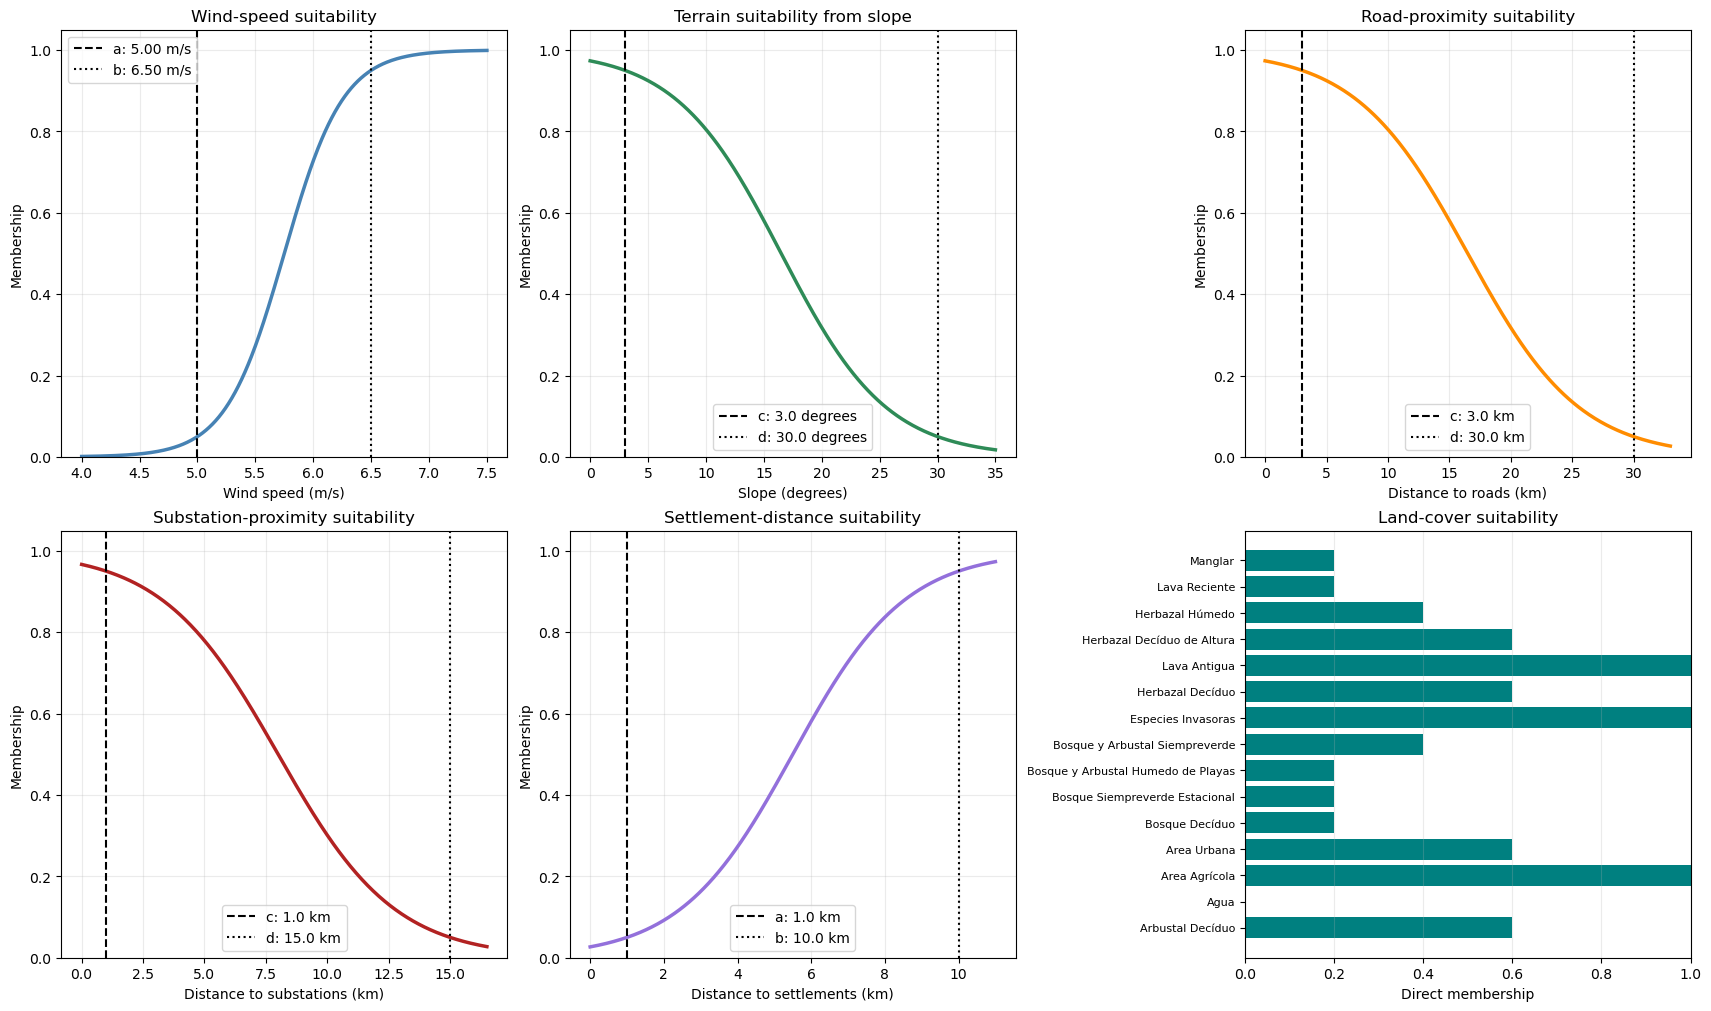

In [24]:
# Print and plot the fuzzy membership functions used by the wind suitability model.
# Run the configuration and utility cells first so PARAMS, INPUTS, and helper functions are available.
import matplotlib.pyplot as plt


def plot_wind_fuzzy_membership_functions(params, inputs):
    wind_controls = params["wind"]["control_points"]
    slope_controls = params["slope"]["control_points"]
    roads_controls = params["roads"]["control_points"]
    substations_controls = params["substations"]["control_points"]
    urban_controls = params["urban"]["control_points"]

    wind_a, wind_b = float(wind_controls["a"]), float(wind_controls["b"])
    slope_c, slope_d = float(slope_controls["c"]), float(slope_controls["d"])
    roads_c, roads_d = float(roads_controls["c"]), float(roads_controls["d"])
    substations_c, substations_d = float(substations_controls["c"]), float(substations_controls["d"])
    urban_a, urban_b = float(urban_controls["a"]), float(urban_controls["b"])

    wind_values = np.linspace(max(0.0, wind_a - 1.0), wind_b + 1.0, 500)
    slope_values = np.linspace(0.0, max(35.0, slope_d * 1.1), 500)
    roads_distance = np.linspace(0.0, roads_d * 1.1, 500)
    substations_distance = np.linspace(0.0, substations_d * 1.1, 500)
    urban_distance = np.linspace(0.0, urban_b * 1.1, 500)

    wind_membership = _fuzzy_sigmoid_increasing(wind_values, wind_a, wind_b)
    slope_membership = _fuzzy_sigmoid_decreasing(slope_values, slope_c, slope_d)
    roads_membership = _fuzzy_sigmoid_decreasing(roads_distance, roads_c, roads_d)
    substations_membership = _fuzzy_sigmoid_decreasing(substations_distance, substations_c, substations_d)
    urban_membership = _fuzzy_sigmoid_increasing(urban_distance, urban_a, urban_b)
    land_cover_remap = _load_land_cover_remap(inputs["land_cover_remap"])

    print("Fuzzy membership functions in use:")
    print(f"  Wind speed: increasing sigmoid, 0.05 at {wind_a:.2f} m/s and 0.95 at {wind_b:.2f} m/s")
    print(f"  Slope: decreasing sigmoid, 0.95 at {slope_c:.2f} degrees and 0.05 at {slope_d:.2f} degrees")
    print(f"  Roads: decreasing sigmoid, 0.95 at {roads_c:,.0f} m and 0.05 at {roads_d:,.0f} m")
    print(f"  Substations: decreasing sigmoid, 0.95 at {substations_c:,.0f} m and 0.05 at {substations_d:,.0f} m")
    print(f"  Settlements: increasing sigmoid, 0.05 at {urban_a:,.0f} m and 0.95 at {urban_b:,.0f} m")
    print("  Land cover: direct membership values from remap_eolico_fuzzy.csv")
    print()
    print("Land-cover memberships:")
    for class_name, membership in sorted(land_cover_remap.items()):
        print(f"  {class_name}: {membership:.2f}")

    figure, axes = plt.subplots(2, 3, figsize=(17, 10), constrained_layout=True)
    axes = axes.ravel()

    axes[0].plot(wind_values, wind_membership, color="steelblue", linewidth=2.5)
    axes[0].axvline(wind_a, color="black", linestyle="--", label=f"a: {wind_a:.2f} m/s")
    axes[0].axvline(wind_b, color="black", linestyle=":", label=f"b: {wind_b:.2f} m/s")
    axes[0].set(title="Wind-speed suitability", xlabel="Wind speed (m/s)", ylabel="Membership")
    axes[0].legend()

    axes[1].plot(slope_values, slope_membership, color="seagreen", linewidth=2.5)
    axes[1].axvline(slope_c, color="black", linestyle="--", label=f"c: {slope_c:.1f} degrees")
    axes[1].axvline(slope_d, color="black", linestyle=":", label=f"d: {slope_d:.1f} degrees")
    axes[1].set(title="Terrain suitability from slope", xlabel="Slope (degrees)", ylabel="Membership")
    axes[1].legend()

    axes[2].plot(roads_distance / 1000.0, roads_membership, color="darkorange", linewidth=2.5)
    axes[2].axvline(roads_c / 1000.0, color="black", linestyle="--", label=f"c: {roads_c / 1000.0:.1f} km")
    axes[2].axvline(roads_d / 1000.0, color="black", linestyle=":", label=f"d: {roads_d / 1000.0:.1f} km")
    axes[2].set(title="Road-proximity suitability", xlabel="Distance to roads (km)", ylabel="Membership")
    axes[2].legend()

    axes[3].plot(substations_distance / 1000.0, substations_membership, color="firebrick", linewidth=2.5)
    axes[3].axvline(substations_c / 1000.0, color="black", linestyle="--", label=f"c: {substations_c / 1000.0:.1f} km")
    axes[3].axvline(substations_d / 1000.0, color="black", linestyle=":", label=f"d: {substations_d / 1000.0:.1f} km")
    axes[3].set(title="Substation-proximity suitability", xlabel="Distance to substations (km)", ylabel="Membership")
    axes[3].legend()

    axes[4].plot(urban_distance / 1000.0, urban_membership, color="mediumpurple", linewidth=2.5)
    axes[4].axvline(urban_a / 1000.0, color="black", linestyle="--", label=f"a: {urban_a / 1000.0:.1f} km")
    axes[4].axvline(urban_b / 1000.0, color="black", linestyle=":", label=f"b: {urban_b / 1000.0:.1f} km")
    axes[4].set(title="Settlement-distance suitability", xlabel="Distance to settlements (km)", ylabel="Membership")
    axes[4].legend()

    class_names = list(land_cover_remap)
    memberships = [land_cover_remap[class_name] for class_name in class_names]
    axes[5].barh(class_names, memberships, color="teal")
    axes[5].set(title="Land-cover suitability", xlabel="Direct membership", xlim=(0.0, 1.0))
    axes[5].tick_params(axis="y", labelsize=8)
    axes[5].grid(axis="x", alpha=0.25)

    for axis in axes[:5]:
        axis.set_ylim(0.0, 1.05)
        axis.grid(alpha=0.25)

    plt.show()


plot_wind_fuzzy_membership_functions(PARAMS, INPUTS)

In [25]:
# Wind raster preprocessing: summarize the observed distribution for diagnostics.
# Membership settings remain the fixed control points configured in PARAMS["wind"].
with rasterio.open(INPUTS["wind_speed_raster"]) as src:
    wind_values = src.read(1).astype("float32")

valid_wind = wind_values[np.isfinite(wind_values)]
summary = {
    "min": float(valid_wind.min()),
    "max": float(valid_wind.max()),
    "mean": float(valid_wind.mean()),
    "median": float(np.median(valid_wind)),
    "p05": float(np.percentile(valid_wind, 5)),
    "p10": float(np.percentile(valid_wind, 10)),
    "p25": float(np.percentile(valid_wind, 25)),
    "p50": float(np.percentile(valid_wind, 50)),
    "p75": float(np.percentile(valid_wind, 75)),
    "p90": float(np.percentile(valid_wind, 90)),
    "p95": float(np.percentile(valid_wind, 95)),
}

print("Wind raster summary (m/s):")
for key in ["min", "max", "mean", "median", "p05", "p10", "p25", "p50", "p75", "p90", "p95"]:
    print(f"  {key}: {summary[key]:.4f}")

wind_controls = PARAMS["wind"]["control_points"]
print(f"Wind membership uses fixed controls: a={wind_controls['a']:.2f} m/s, b={wind_controls['b']:.2f} m/s.")

Wind raster summary (m/s):
  min: 1.3691
  max: 10.1207
  mean: 4.3822
  median: 4.2841
  p05: 2.1537
  p10: 2.4192
  p25: 3.0682
  p50: 4.2841
  p75: 5.4520
  p90: 6.4309
  p95: 7.1937
Wind membership uses fixed controls: a=5.00 m/s, b=6.50 m/s.


In [26]:
def _save_raster(path, array, template_profile, nodata_value=-9999.0):
    p = Path(path)
    p.parent.mkdir(parents=True, exist_ok=True)
    profile = template_profile.copy()
    profile.update(
        dtype="float32",
        count=1,
        compress="lzw",
        nodata=nodata_value,
    )
    data = np.where(np.isfinite(array), array, nodata_value).astype("float32")

    with rasterio.open(p, "w", **profile) as dst:
        dst.write(data, 1)
    return str(p)


def _with_scenario_label(path, scenario_label):
    p = Path(path)
    return str(p.with_name(f"{p.stem}_{scenario_label}{p.suffix}"))


def _polygonize_candidates(candidate_array, transform, crs):
    features = []
    for geom, val in shapes(candidate_array, transform=transform):
        if val == 1:
            features.append({"geometry": geom, "properties": {"suitability": 1}})

    if not features:
        return gpd.GeoDataFrame({"suitability": [], "area_m2": []}, geometry=[], crs=crs)

    gdf = gpd.GeoDataFrame.from_features(features, crs=crs)
    gdf["area_m2"] = gdf.geometry.area
    return gdf

In [27]:
def run_wind_suitability(inputs, params, weights, outputs):
    _require_non_empty(inputs, "INPUTS")
    _require_non_empty(outputs, "OUTPUTS")
    _validate_weights(weights)
    if params.get("threshold") is None:
        raise ValueError("PARAMS['threshold'] is empty.")

    save_intermediate_results = bool(params.get("save_intermediate_results", SAVE_INTERMEDIATE_RESULTS))
    scenario_name = params.get("weight_scenario", "default")
    scenario_label = re.sub(r"[^A-Za-z0-9_-]+", "_", str(scenario_name)).strip("_")
    timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
    run_outputs = {
        key: _with_timestamp_label(_with_scenario_label(path, scenario_label), timestamp)
        for key, path in outputs.items()
    }
    outputs.update(run_outputs)

    analysis_crs = params.get("analysis_crs", "EPSG:32715")
    projected_dem_profile = _project_raster_profile(inputs["dem"], analysis_crs)
    transform = projected_dem_profile["transform"]
    crs = projected_dem_profile["crs"]
    shape = (projected_dem_profile["height"], projected_dem_profile["width"])
    boundary = gpd.read_file(inputs["galapagos_boundary"]).to_crs(crs)

    dem_projected = _reproject_to_template(inputs["dem"], projected_dem_profile, Resampling.bilinear)
    dem_clipped = _clip_array_to_boundary(dem_projected, transform, boundary)
    if "dem_clipped" in outputs and save_intermediate_results:
        outputs["dem_clipped"] = _save_raster(outputs["dem_clipped"], dem_clipped, projected_dem_profile)

    wind_controls = params["wind"]["control_points"]
    slope_controls = params["slope"]["control_points"]
    roads_controls = params["roads"]["control_points"]
    substations_controls = params["substations"]["control_points"]
    urban_controls = params["urban"]["control_points"]

    slope_degrees = _slope_from_dem(dem_clipped, transform)
    terrain_reclass = _fuzzy_sigmoid_decreasing(
        slope_degrees, slope_controls["c"], slope_controls["d"]
    )

    roads = gpd.clip(gpd.read_file(inputs["roads"]).to_crs(crs), boundary)
    substations = gpd.clip(gpd.read_file(inputs["substations"]).to_crs(crs), boundary)
    poblados = gpd.clip(gpd.read_file(inputs["poblados"]).to_crs(crs), boundary)
    land_cover = gpd.read_file(inputs["land_cover"]).to_crs(crs)

    # Land cover deliberately retains its direct class-to-membership remap.
    land_cover_remap = _load_land_cover_remap(inputs["land_cover_remap"])
    land_cover_field = _detect_land_cover_field(
        land_cover, land_cover_remap, preferred_field=params.get("land_cover_field")
    )
    land_cover_reclass = _rasterize_land_cover_reclass(
        land_cover, shape, transform, land_cover_remap, land_cover_field
    )
    land_cover_reclass = _clip_array_to_boundary(land_cover_reclass, transform, boundary)

    wind_speed = _reproject_to_template(inputs["wind_speed_raster"], projected_dem_profile, Resampling.bilinear)
    wind_speed_clip = _clip_array_to_boundary(wind_speed, transform, boundary)
    wind_reclass = _fuzzy_sigmoid_increasing(
        wind_speed_clip, wind_controls["a"], wind_controls["b"]
    )

    roads_raster = _rasterize_features(roads, shape, transform)
    sub_raster = _rasterize_features(substations, shape, transform)
    poblados_raster = _rasterize_features(poblados, shape, transform)
    boundary_mask = np.isfinite(dem_clipped)
    roads_dist = _distance_within_boundary_components(roads_raster, boundary_mask, transform)
    sub_dist = _distance_within_boundary_components(sub_raster, boundary_mask, transform)
    poblados_dist = _distance_within_boundary_components(poblados_raster, boundary_mask, transform)

    roads_reclass = _fuzzy_sigmoid_decreasing(roads_dist, roads_controls["c"], roads_controls["d"])
    substations_reclass = _fuzzy_sigmoid_decreasing(
        sub_dist, substations_controls["c"], substations_controls["d"]
    )
    poblados_reclass = _fuzzy_sigmoid_increasing(
        poblados_dist, urban_controls["a"], urban_controls["b"]
    )

    # Islands without the corresponding feature retain their lowest membership.
    substations_reclass[boundary_mask & ~np.isfinite(sub_dist)] = 0.0
    poblados_reclass[boundary_mask & ~np.isfinite(poblados_dist)] = 0.0

    suitability = _weighted_sum(
        wind_reclass, terrain_reclass, roads_reclass, substations_reclass,
        land_cover_reclass, poblados_reclass, weights,
    )
    threshold = float(params["threshold"])
    candidate = np.where(suitability >= threshold, suitability, np.nan).astype("float32")

    if save_intermediate_results:
        for key, value in [
            ("slope_degrees", slope_degrees), ("terrain_reclass", terrain_reclass),
            ("wind_reclass", wind_reclass), ("roads_distance", roads_dist),
            ("roads_reclass", roads_reclass), ("substations_distance", sub_dist),
            ("substations_reclass", substations_reclass), ("poblados_distance", poblados_dist),
            ("poblados_reclass", poblados_reclass), ("land_cover_reclass", land_cover_reclass),
        ]:
            if key in outputs:
                outputs[key] = _save_raster(outputs[key], value, projected_dem_profile)

    outputs["weighted_suitability"] = _save_raster(
        outputs["weighted_suitability"], suitability, projected_dem_profile
    )
    outputs["candidate_raster"] = _save_raster(
        outputs["candidate_raster"], candidate, projected_dem_profile
    )
    candidates_gdf = _polygonize_candidates(candidate, transform, crs)
    out_vector = Path(outputs["candidate_polygons"])
    out_vector.parent.mkdir(parents=True, exist_ok=True)
    if str(out_vector).lower().endswith(".shp"):
        candidates_gdf.to_file(out_vector)
    else:
        candidates_gdf.to_file(out_vector, driver="GPKG")

    return {
        "timestamp": timestamp,
        "threshold": threshold,
        "weight_scenario": scenario_name,
        "weights": weights.copy(),
        "save_intermediate_results": save_intermediate_results,
        "n_candidate_polygons": len(candidates_gdf),
        "total_candidate_area_m2": float(candidates_gdf["area_m2"].sum()) if len(candidates_gdf) else 0.0,
        "land_cover_field_used": land_cover_field,
        "analysis_crs": str(crs),
        "roads_distance_output": outputs.get("roads_distance"),
        "candidate_polygons_output": outputs["candidate_polygons"],
        "substations_distance_output": outputs.get("substations_distance"),
        "weighted_suitability_output": outputs["weighted_suitability"],
        "poblados_distance_output": outputs.get("poblados_distance"),
    }

In [28]:
# Memory-safe distance accumulation for large grids.
# It adaptively downsamples the binary feature raster for EDT and upsamples back to the full grid.
def _distance_to_features(feature_raster, transform, max_cells=25_000_000):
    pixel_size_y = abs(transform.e)
    pixel_size_x = abs(transform.a)
    feature_mask = feature_raster == 1
    if not np.any(feature_mask):
        raise ValueError("No feature pixels found after rasterization.")

    height, width = feature_raster.shape
    total_cells = height * width
    factor = int(np.ceil(np.sqrt(total_cells / max_cells))) if total_cells > max_cells else 1

    if factor <= 1:
        distance = distance_transform_edt(
            ~feature_mask,
            sampling=(pixel_size_y, pixel_size_x),
        )
        return distance.astype("float32")

    # Max-pool to preserve any feature pixel in coarse blocks.
    coarse_h = int(np.ceil(height / factor))
    coarse_w = int(np.ceil(width / factor))
    pad_h = coarse_h * factor - height
    pad_w = coarse_w * factor - width
    padded = np.pad(
        feature_mask,
        ((0, pad_h), (0, pad_w)),
        mode="constant",
        constant_values=False,
    )
    coarse_mask = padded.reshape(coarse_h, factor, coarse_w, factor).max(axis=(1, 3))

    coarse_distance = distance_transform_edt(
        ~coarse_mask,
        sampling=(pixel_size_y * factor, pixel_size_x * factor),
    ).astype("float32")

    # Nearest-neighbor upsample back to original shape.
    distance = np.repeat(np.repeat(coarse_distance, factor, axis=0), factor, axis=1)
    distance = distance[:height, :width]
    return distance.astype("float32")

{'timestamp': '20260912_185247', 'threshold': 0.7, 'weight_scenario': 'scenario_1', 'weights': {'wind': 0.45, 'terrain': 0.2, 'roads': 0.1, 'substations': 0.05, 'landuse': 0.15, 'poblados': 0.05}, 'save_intermediate_results': False, 'n_candidate_polygons': 0, 'total_candidate_area_m2': 0.0, 'land_cover_field_used': 'Ecosis_Nat', 'analysis_crs': 'EPSG:32715', 'roads_distance_output': None, 'candidate_polygons_output': 'C:\\HyGalapagos\\outputs_eolico\\scenario_1\\candidate_polygons_scenario_1_20260912_185247.gpkg', 'substations_distance_output': None, 'weighted_suitability_output': 'C:\\HyGalapagos\\outputs_eolico\\scenario_1\\weighted_suitability_scenario_1_20260912_185247.tif', 'poblados_distance_output': None}


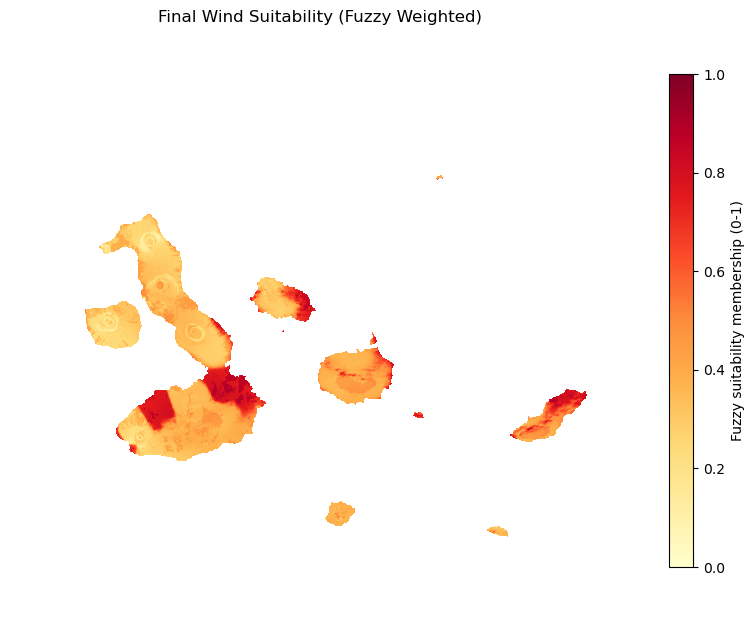

In [29]:
# Run analysis and visualize final fuzzy suitability map.
result = run_wind_suitability(INPUTS, PARAMS, WEIGHTS, OUTPUTS)
print(result)

import matplotlib.pyplot as plt
import rasterio

with rasterio.open(OUTPUTS["weighted_suitability"]) as src:
    suitability = src.read(1).astype("float32")
    nodata = src.nodata
    if nodata is not None:
        suitability[suitability == nodata] = np.nan

plt.figure(figsize=(10, 8))
im = plt.imshow(suitability, cmap="YlOrRd", vmin=0.0, vmax=1.0)
plt.title("Final Wind Suitability (Fuzzy Weighted)")
plt.axis("off")
cbar = plt.colorbar(im, shrink=0.8)
cbar.set_label("Fuzzy suitability membership (0-1)")
plt.show()

In [30]:
# Diagnostics for CRS and output ranges.
inspect_paths = [
    OUTPUTS["dem_clipped"],
    OUTPUTS["roads_distance"],
    OUTPUTS["roads_reclass"],
    OUTPUTS["substations_distance"],
    OUTPUTS["substations_reclass"],
    OUTPUTS["poblados_distance"],
    OUTPUTS["poblados_reclass"],
    OUTPUTS["wind_reclass"],
    OUTPUTS["weighted_suitability"],
]

for inspect_path in inspect_paths:
    with rasterio.open(inspect_path) as src:
        arr = src.read(1).astype("float32")
        if src.nodata is not None:
            arr[arr == src.nodata] = np.nan
        finite = arr[np.isfinite(arr)]
        unique_vals = np.unique(finite) if finite.size else np.array([])
        print(inspect_path)
        print("  crs:", src.crs)
        print("  transform:", src.transform)
        print("  min/max:", float(np.nanmin(arr)), float(np.nanmax(arr)))

        print("  unique sample:", unique_vals[:10])        
        print("  unique count:", len(unique_vals))

KeyError: 'dem_clipped'

In [ ]:
# Check substation coverage by individual boundary polygons (islands).
analysis_crs = PARAMS.get("analysis_crs", "EPSG:32715")
boundary_check = gpd.read_file(INPUTS["galapagos_boundary"]).to_crs(analysis_crs)
substations_check = gpd.read_file(INPUTS["substations"]).to_crs(analysis_crs)

islands = boundary_check.explode(index_parts=False).reset_index(drop=True)
islands["island_id"] = islands.index + 1
join = gpd.sjoin(substations_check, islands[["island_id", "geometry"]], how="left", predicate="within")
counts = join.groupby("island_id").size()

print("Total substations:", len(substations_check))
print("Substations inside boundary polygons:", int(counts.sum()))
print("Islands with >=1 substation:", int(counts.index.nunique()))
print("Total island polygons:", len(islands))
print("Island IDs without substations:", [i for i in islands["island_id"].tolist() if i not in set(counts.index.tolist())][:25])

Total substations: 12
Substations inside boundary polygons: 12
Islands with >=1 substation: 7
Total island polygons: 235
Island IDs without substations: [2, 3, 4, 5, 6, 7, 8, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27]


In [ ]:
# Export eolic area and generation potential by island and in total.
from rasterio.mask import mask
import pandas as pd

ROOT = Path(r"C:/HyGalapagos")
BASE_ROOT = Path(r"C:/Galapagos_IERSE/01_Organizacion_Territorial")
EOLIC_RASTER = ROOT / "outputs_eolico/cost_raster_24_04.tif"
ISLAND_FILES = {
    "Isabela": BASE_ROOT / "solo_isabela.shp",
    "Floreana": BASE_ROOT / "floreana.shp",
    "Santa Cruz": BASE_ROOT / "santa_cruz_baltra.shp",
    "San Cristobal": BASE_ROOT / "san_cristobal.shp",
}

EOLIC_HA_PER_MW = 0.9

# Use the weighted suitability raster produced by the current wind run.
if "result" in globals() and isinstance(result, dict):
    eolic_run_raster = result.get("weighted_suitability_output")
    if eolic_run_raster:
        EOLIC_RASTER = Path(eolic_run_raster)

if not EOLIC_RASTER.exists():
    raise FileNotFoundError(f"Eolic raster not found: {EOLIC_RASTER}")

run_timestamp = result.get("timestamp", "unknown") if "result" in globals() else "unknown"
scenario_name = result.get("weight_scenario", "unknown") if "result" in globals() else "unknown"
POTENTIAL_CSV = EOLIC_RASTER.parent / f"eolic_potential_summary_{scenario_name}_{run_timestamp}.csv"


def calculate_eolic_potential_by_island(raster_path, ha_per_mw):
    rows = []
    total_area_ha = 0.0

    with rasterio.open(raster_path) as src:
        pixel_area_ha = abs(src.transform.a * src.transform.e) / 10000.0

        for island_name, island_path in ISLAND_FILES.items():
            island = gpd.read_file(island_path).to_crs(src.crs)
            island_geometry = [geometry for geometry in island.geometry if geometry is not None and not geometry.is_empty]

            try:
                data, _ = mask(src, island_geometry, crop=True, filled=False)
                values = data[0]
                valid = np.isfinite(values) & (~values.mask)
                suitable = valid & (values > 0)
                suitable_pixels = int(np.sum(suitable))
                area_ha = suitable_pixels * pixel_area_ha
                suitability_mean = float(np.mean(values[suitable])) if suitable_pixels else np.nan
            except ValueError:
                area_ha = 0.0
                suitability_mean = np.nan

            total_area_ha += area_ha
            rows.append({
                "technology": "eolic",
                "island": island_name,
                "suitable_area_ha": area_ha,
                "potential_mw": area_ha / ha_per_mw,
                "suitability_mean": suitability_mean,
                "weight_scenario": scenario_name,
                "run_timestamp": run_timestamp,
            })

    rows.append({
        "technology": "eolic",
        "island": "TOTAL",
        "suitable_area_ha": total_area_ha,
        "potential_mw": total_area_ha / ha_per_mw,
        "suitability_mean": np.nan,
        "weight_scenario": scenario_name,
        "run_timestamp": run_timestamp,
    })
    return rows


summary = pd.DataFrame(calculate_eolic_potential_by_island(EOLIC_RASTER, EOLIC_HA_PER_MW))
POTENTIAL_CSV.parent.mkdir(parents=True, exist_ok=True)
summary.to_csv(POTENTIAL_CSV, index=False)

print("Eolic potential summary CSV:", POTENTIAL_CSV)
print(summary.to_string(index=False))

Eolic potential summary CSV: C:\HyGalapagos\outputs_eolico\scenario_2\eolic_potential_summary_scenario_2_20260826_124422.csv
technology        island  suitable_area_ha  potential_mw  suitability_mean weight_scenario   run_timestamp
     eolic       Isabela     467382.794968 519314.216631          0.365714      scenario_2 20260826_124422
     eolic      Floreana      16965.556055  18850.617839          0.569227      scenario_2 20260826_124422
     eolic    Santa Cruz      99974.558553 111082.842837          0.571854      scenario_2 20260826_124422
     eolic San Cristobal      55113.371116  61237.079018          0.623463      scenario_2 20260826_124422
     eolic         TOTAL     639436.280692 710484.756324               NaN      scenario_2 20260826_124422
